# Cross Validation of NMF

In [ ]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

sns.set("talk", "ticks", palette='colorblind')

## Write the Nonnegative Matrix Factorization Code that can handle missing data

In [ ]:
import numpy as np
import scipy.optimize as opt
import scipy.sparse as sps
import numpy.linalg as nla
import scipy.linalg as sla
import time


def nnlsm_blockpivot(A, B, is_input_prod=False, init=None):
    """ Nonnegativity-constrained least squares with block principal pivoting method and column grouping

    Solves min ||AX-B||_2^2 s.t. X >= 0 element-wise.

    J. Kim and H. Park, Fast nonnegative matrix factorization: An active-set-like method and comparisons,
    SIAM Journal on Scientific Computing,
    vol. 33, no. 6, pp. 3261-3281, 2011.

    Parameters
    ----------
    A : numpy.array, shape (m,n)
    B : numpy.array or scipy.sparse matrix, shape (m,k)

    Optional Parameters
    -------------------
    is_input_prod : True/False. -  If True, the A and B arguments are interpreted as
            AtA and AtB, respectively. Default is False.
    init: numpy.array, shape (n,k). - If provided, init is used as an initial value for the algorithm.
            Default is None.

    Returns
    -------
    X, (success, Y, num_cholesky, num_eq, num_backup)
    X : numpy.array, shape (n,k) - solution
    success : True/False - True if the solution is found. False if the algorithm did not terminate
            due to numerical errors.
    Y : numpy.array, shape (n,k) - Y = A.T * A * X - A.T * B
    num_cholesky : int - the number of Cholesky factorizations needed
    num_eq : int - the number of linear systems of equations needed to be solved
    num_backup: int - the number of appearances of the back-up rule. See SISC paper for details.
    """
    if is_input_prod:
        AtA = A
        AtB = B
    else:
        AtA = A.T.dot(A)
        if sps.issparse(B):
            AtB = B.T.dot(A)
            AtB = AtB.T
        else:
            AtB = A.T.dot(B)

    (n, k) = AtB.shape
    MAX_ITER = n * 5

    if init is not  None:
        PassSet = init > 0
        X, num_cholesky, num_eq = normal_eq_comb(AtA, AtB, PassSet)
        Y = AtA.dot(X) - AtB
    else:
        X = np.zeros([n, k])
        Y = -AtB
        PassSet = np.zeros([n, k], dtype=bool)
        num_cholesky = 0
        num_eq = 0

    p_bar = 3
    p_vec = np.zeros([k])
    p_vec[:] = p_bar
    ninf_vec = np.zeros([k])
    ninf_vec[:] = n + 1
    not_opt_set = np.logical_and(Y < 0, ~PassSet)
    infea_set = np.logical_and(X < 0, PassSet)

    not_good = np.sum(not_opt_set, axis=0) + np.sum(infea_set, axis=0)
    not_opt_colset = not_good > 0
    not_opt_cols = not_opt_colset.nonzero()[0]

    big_iter = 0
    num_backup = 0
    success = True
    while not_opt_cols.size > 0:
        big_iter += 1
        if MAX_ITER > 0 and big_iter > MAX_ITER:
            success = False
            break

        cols_set1 = np.logical_and(not_opt_colset, not_good < ninf_vec)
        temp1 = np.logical_and(not_opt_colset, not_good >= ninf_vec)
        temp2 = p_vec >= 1
        cols_set2 = np.logical_and(temp1, temp2)
        cols_set3 = np.logical_and(temp1, ~temp2)

        cols1 = cols_set1.nonzero()[0]
        cols2 = cols_set2.nonzero()[0]
        cols3 = cols_set3.nonzero()[0]

        if cols1.size > 0:
            p_vec[cols1] = p_bar
            ninf_vec[cols1] = not_good[cols1]
            true_set = np.logical_and(not_opt_set, np.tile(cols_set1, (n, 1)))
            false_set = np.logical_and(infea_set, np.tile(cols_set1, (n, 1)))
            PassSet[true_set] = True
            PassSet[false_set] = False
        if cols2.size > 0:
            p_vec[cols2] = p_vec[cols2] - 1
            temp_tile = np.tile(cols_set2, (n, 1))
            true_set = np.logical_and(not_opt_set, temp_tile)
            false_set = np.logical_and(infea_set, temp_tile)
            PassSet[true_set] = True
            PassSet[false_set] = False
        if cols3.size > 0:
            for col in cols3:
                candi_set = np.logical_or(
                    not_opt_set[:, col], infea_set[:, col])
                to_change = np.max(candi_set.nonzero()[0])
                PassSet[to_change, col] = ~PassSet[to_change, col]
                num_backup += 1

        (X[:, not_opt_cols], temp_cholesky, temp_eq) = normal_eq_comb(
            AtA, AtB[:, not_opt_cols], PassSet[:, not_opt_cols])
        num_cholesky += temp_cholesky
        num_eq += temp_eq
        X[abs(X) < 1e-12] = 0
        Y[:, not_opt_cols] = AtA.dot(X[:, not_opt_cols]) - AtB[:, not_opt_cols]
        Y[abs(Y) < 1e-12] = 0

        not_opt_mask = np.tile(not_opt_colset, (n, 1))
        not_opt_set = np.logical_and(
            np.logical_and(not_opt_mask, Y < 0), ~PassSet)
        infea_set = np.logical_and(
            np.logical_and(not_opt_mask, X < 0), PassSet)
        not_good = np.sum(not_opt_set, axis=0) + np.sum(infea_set, axis=0)
        not_opt_colset = not_good > 0
        not_opt_cols = not_opt_colset.nonzero()[0]

    return X, (success, Y, num_cholesky, num_eq, num_backup)


def nnlsm_activeset(A, B, overwrite=False, is_input_prod=False, init=None):
    """ Nonnegativity-constrained least squares with active-set method and column grouping

    Solves min ||AX-B||_2^2 s.t. X >= 0 element-wise.

    Algorithm of this routine is close to the one presented in the following paper but
    is different in organising inner- and outer-loops:
    M. H. Van Benthem and M. R. Keenan, J. Chemometrics 2004; 18: 441-450

    Parameters
    ----------
    A : numpy.array, shape (m,n)
    B : numpy.array or scipy.sparse matrix, shape (m,k)

    Optional Parameters
    -------------------
    is_input_prod : True/False. -  If True, the A and B arguments are interpreted as
            AtA and AtB, respectively. Default is False.
    init: numpy.array, shape (n,k). - If provided, init is used as an initial value for the algorithm.
            Default is None.

    Returns
    -------
    X, (success, Y, num_cholesky, num_eq, num_backup)
    X : numpy.array, shape (n,k) - solution
    success : True/False - True if the solution is found. False if the algorithm did not terminate
            due to numerical errors.
    Y : numpy.array, shape (n,k) - Y = A.T * A * X - A.T * B
    num_cholesky : int - the number of Cholesky factorizations needed
    num_eq : int - the number of linear systems of equations needed to be solved
    """
    if is_input_prod:
        AtA = A
        AtB = B
    else:
        AtA = A.T.dot(A)
        if sps.issparse(B):
            AtB = B.T.dot(A)
            AtB = AtB.T
        else:
            AtB = A.T.dot(B)

    (n, k) = AtB.shape
    MAX_ITER = n * 5
    num_cholesky = 0
    num_eq = 0
    not_opt_set = np.ones([k], dtype=bool)

    if overwrite:
        X, num_cholesky, num_eq = normal_eq_comb(AtA, AtB)
        PassSet = X > 0
        not_opt_set = np.any(X < 0, axis=0)
    elif init is not None:
        X = init
        X[X < 0] = 0
        PassSet = X > 0
    else:
        X = np.zeros([n, k])
        PassSet = np.zeros([n, k], dtype=bool)

    Y = np.zeros([n, k])
    opt_cols = (~not_opt_set).nonzero()[0]
    not_opt_cols = not_opt_set.nonzero()[0]

    Y[:, opt_cols] = AtA.dot(X[:, opt_cols]) - AtB[:, opt_cols]

    big_iter = 0
    success = True
    while not_opt_cols.size > 0:
        big_iter += 1
        if MAX_ITER > 0 and big_iter > MAX_ITER:
            success = False
            break

        (Z, temp_cholesky, temp_eq) = normal_eq_comb(
            AtA, AtB[:, not_opt_cols], PassSet[:, not_opt_cols])
        num_cholesky += temp_cholesky
        num_eq += temp_eq

        Z[abs(Z) < 1e-12] = 0

        infea_subset = Z < 0
        temp = np.any(infea_subset, axis=0)
        infea_subcols = temp.nonzero()[0]
        fea_subcols = (~temp).nonzero()[0]

        if infea_subcols.size > 0:
            infea_cols = not_opt_cols[infea_subcols]

            (ix0, ix1_subsub) = infea_subset[:, infea_subcols].nonzero()
            ix1_sub = infea_subcols[ix1_subsub]
            ix1 = not_opt_cols[ix1_sub]

            X_infea = X[(ix0, ix1)]

            alpha = np.zeros([n, len(infea_subcols)])
            alpha[:] = np.inf
            alpha[(ix0, ix1_subsub)] = X_infea / (X_infea - Z[(ix0, ix1_sub)])
            min_ix = np.argmin(alpha, axis=0)
            min_vals = alpha[(min_ix, range(0, alpha.shape[1]))]

            X[:, infea_cols] = X[:, infea_cols] + \
                (Z[:, infea_subcols] - X[:, infea_cols]) * min_vals
            X[(min_ix, infea_cols)] = 0
            PassSet[(min_ix, infea_cols)] = False

        elif fea_subcols.size > 0:
            fea_cols = not_opt_cols[fea_subcols]

            X[:, fea_cols] = Z[:, fea_subcols]
            Y[:, fea_cols] = AtA.dot(X[:, fea_cols]) - AtB[:, fea_cols]

            Y[abs(Y) < 1e-12] = 0

            not_opt_subset = np.logical_and(
                Y[:, fea_cols] < 0, ~PassSet[:, fea_cols])
            new_opt_cols = fea_cols[np.all(~not_opt_subset, axis=0)]
            update_cols = fea_cols[np.any(not_opt_subset, axis=0)]

            if update_cols.size > 0:
                val = Y[:, update_cols] * ~PassSet[:, update_cols]
                min_ix = np.argmin(val, axis=0)
                PassSet[(min_ix, update_cols)] = True

            not_opt_set[new_opt_cols] = False
            not_opt_cols = not_opt_set.nonzero()[0]

    return X, (success, Y, num_cholesky, num_eq)


def normal_eq_comb(AtA, AtB, PassSet=None):
    """ Solve many systems of linear equations using combinatorial grouping.

    M. H. Van Benthem and M. R. Keenan, J. Chemometrics 2004; 18: 441-450

    Parameters
    ----------
    AtA : numpy.array, shape (n,n)
    AtB : numpy.array, shape (n,k)

    Returns
    -------
    (Z,num_cholesky,num_eq)
    Z : numpy.array, shape (n,k) - solution
    num_cholesky : int - the number of unique cholesky decompositions done
    num_eq: int - the number of systems of linear equations solved
    """
    num_cholesky = 0
    num_eq = 0
    if AtB.size == 0:
        Z = np.zeros([])
    elif (PassSet is None) or np.all(PassSet):
        Z = nla.solve(AtA, AtB)
        num_cholesky = 1
        num_eq = AtB.shape[1]
    else:
        Z = np.zeros(AtB.shape)
        if PassSet.shape[1] == 1:
            if np.any(PassSet):
                cols = PassSet.nonzero()[0]
                Z[cols] = nla.solve(AtA[np.ix_(cols, cols)], AtB[cols])
                num_cholesky = 1
                num_eq = 1
        else:
            #
            # Both _column_group_loop() and _column_group_recursive() work well.
            # Based on preliminary testing,
            # _column_group_loop() is slightly faster for tiny k(<10), but
            # _column_group_recursive() is faster for large k's.
            #
            grps = _column_group_recursive(PassSet)
            for gr in grps:
                cols = PassSet[:, gr[0]].nonzero()[0]
                if cols.size > 0:
                    ix1 = np.ix_(cols, gr)
                    ix2 = np.ix_(cols, cols)
                    #
                    # scipy.linalg.cho_solve can be used instead of numpy.linalg.solve.
                    # For small n(<200), numpy.linalg.solve appears faster, whereas
                    # for large n(>500), scipy.linalg.cho_solve appears faster.
                    # Usage example of scipy.linalg.cho_solve:
                    # Z[ix1] = sla.cho_solve(sla.cho_factor(AtA[ix2]),AtB[ix1])
                    #
                    Z[ix1] = nla.solve(AtA[ix2], AtB[ix1])
                    num_cholesky += 1
                    num_eq += len(gr)
                    num_eq += len(gr)
    return Z, num_cholesky, num_eq


def _column_group_loop(B):
    """ Given a binary matrix, find groups of the same columns
        with a looping strategy

    Parameters
    ----------
    B : numpy.array, True/False in each element

    Returns
    -------
    A list of arrays - each array contain indices of columns that are the same.
    """
    initial = [np.arange(0, B.shape[1])]
    before = initial
    after = []
    for i in range(0, B.shape[0]):
        all_ones = True
        vec = B[i]
        for cols in before:
            if len(cols) == 1:
                after.append(cols)
            else:
                all_ones = False
                subvec = vec[cols]
                trues = subvec.nonzero()[0]
                falses = (~subvec).nonzero()[0]
                if trues.size > 0:
                    after.append(cols[trues])
                if falses.size > 0:
                    after.append(cols[falses])
        before = after
        after = []
        if all_ones:
            break
    return before


def _column_group_recursive(B):
    """ Given a binary matrix, find groups of the same columns
        with a recursive strategy

    Parameters
    ----------
    B : numpy.array, True/False in each element

    Returns
    -------
    A list of arrays - each array contain indices of columns that are the same.
    """
    initial = np.arange(0, B.shape[1])
    return [a for a in column_group_sub(B, 0, initial) if len(a) > 0]


def column_group_sub(B, i, cols):
    vec = B[i][cols]
    if len(cols) <= 1:
        return [cols]
    if i == (B.shape[0] - 1):
        col_trues = cols[vec.nonzero()[0]]
        col_falses = cols[(~vec).nonzero()[0]]
        return [col_trues, col_falses]
    else:
        col_trues = cols[vec.nonzero()[0]]
        col_falses = cols[(~vec).nonzero()[0]]
        after = column_group_sub(B, i + 1, col_trues)
        after.extend(column_group_sub(B, i + 1, col_falses))
    return after


def _test_column_grouping(m=10, n=5000, num_repeat=5, verbose=False):
    print ('\nTesting column_grouping ...\n')
    A = np.array([[True, False, False, False, False],
                  [True, True, False, True, True]])
    grps1 = _column_group_loop(A)
    grps2 = _column_group_recursive(A)
    grps3 = [np.array([0]),
             np.array([1, 3, 4]),
             np.array([2])]
    print ('OK' if all([np.array_equal(a, b) for (a, b) in zip(grps1, grps2)]) else 'Fail')
    print ('OK' if all([np.array_equal(a, b) for (a, b) in zip(grps1, grps3)]) else 'Fail')

    for i in iter(range(0, num_repeat)):
        A = np.random.rand(m, n)
        B = A > 0.5
        start = time.time()
        grps1 = _column_group_loop(B)
        elapsed_loop = time.time() - start
        start = time.time()
        grps2 = _column_group_recursive(B)
        elapsed_recursive = time.time() - start
        if verbose:
            print ('Loop     :', elapsed_loop)
            print ('Recursive:', elapsed_recursive)
        print ('OK' if all([np.array_equal(a, b) for (a, b) in zip(grps1, grps2)]) else 'Fail')
    # sorted_idx = np.concatenate(grps)
    # print B
    # print sorted_idx
    # print B[:,sorted_idx]
    return


def _test_normal_eq_comb(m=10, k=3, num_repeat=5):
    print ('\nTesting normal_eq_comb() ...\n')
    for i in iter(range(0, num_repeat)):
        A = np.random.rand(2 * m, m)
        X = np.random.rand(m, k)
        C = (np.random.rand(m, k) > 0.5)
        X[~C] = 0
        B = A.dot(X)
        B = A.T.dot(B)
        A = A.T.dot(A)
        Sol, a, b = normal_eq_comb(A, B, C)
        print ('OK' if np.allclose(X, Sol) else 'Fail')
    return


def _test_nnlsm():
    print ('\nTesting nnls routines ...\n')
    m = 100
    n = 10
    k = 200
    rep = 5

    for r in iter(range(0, rep)):
        A = np.random.rand(m, n)
        X_org = np.random.rand(n, k)
        X_org[np.random.rand(n, k) < 0.5] = 0
        B = A.dot(X_org)
        # B = np.random.rand(m,k)
        # A = np.random.rand(m,n/2)
        # A = np.concatenate((A,A),axis=1)
        # A = A + np.random.rand(m,n)*0.01
        # B = np.random.rand(m,k)

        import time
        start = time.time()
        C1, info = nnlsm_blockpivot(A, B)
        elapsed2 = time.time() - start
        rel_norm2 = nla.norm(C1 - X_org) / nla.norm(X_org)
        print ('nnlsm_blockpivot:    ', 'OK  ' if info[0] else 'Fail',\
            'elapsed:{0:.4f} error:{1:.4e}'.format(elapsed2, rel_norm2))

        start = time.time()
        C2, info = nnlsm_activeset(A, B)
        num_backup = 0
        elapsed1 = time.time() - start
        rel_norm1 = nla.norm(C2 - X_org) / nla.norm(X_org)
        print ('nnlsm_activeset:     ', 'OK  ' if info[0] else 'Fail',\
            'elapsed:{0:.4f} error:{1:.4e}'.format(elapsed1, rel_norm1))

        import scipy.optimize as opt
        start = time.time()
        C3 = np.zeros([n, k])
        for i in iter(range(0, k)):
            res = opt.nnls(A, B[:, i])
            C3[:, i] = res[0]
        elapsed3 = time.time() - start
        rel_norm3 = nla.norm(C3 - X_org) / nla.norm(X_org)
        print ('scipy.optimize.nnls: ', 'OK  ',\
            'elapsed:{0:.4f} error:{1:.4e}'.format(elapsed3, rel_norm3))

        if num_backup > 0:
            break
        if rel_norm1 > 10e-5 or rel_norm2 > 10e-5 or rel_norm3 > 10e-5:
            break
        print ('')

if __name__ == '__main__':
    _test_column_grouping()
    _test_normal_eq_comb()
    _test_nnlsm()


Testing column_grouping ...

OK
OK
OK
OK
OK
OK
OK

Testing normal_eq_comb() ...

OK
OK
OK
OK
OK

Testing nnls routines ...

nnlsm_blockpivot:     OK   elapsed:0.0035 error:5.7955e-15
nnlsm_activeset:      OK   elapsed:0.0498 error:5.1334e-15
scipy.optimize.nnls:  OK   elapsed:0.0289 error:3.9565e-16

nnlsm_blockpivot:     OK   elapsed:0.0010 error:4.9745e-15
nnlsm_activeset:      OK   elapsed:0.0693 error:4.4041e-15
scipy.optimize.nnls:  OK   elapsed:0.0274 error:4.0130e-16

nnlsm_blockpivot:     OK   elapsed:0.0009 error:6.0547e-15
nnlsm_activeset:      OK   elapsed:0.0567 error:5.2789e-15
scipy.optimize.nnls:  OK   elapsed:0.0207 error:4.4700e-16

nnlsm_blockpivot:     OK   elapsed:0.0014 error:5.2683e-15
nnlsm_activeset:      OK   elapsed:0.0471 error:4.7041e-15
scipy.optimize.nnls:  OK   elapsed:0.0162 error:3.9607e-16

nnlsm_blockpivot:     OK   elapsed:0.0009 error:5.1673e-15
nnlsm_activeset:      OK   elapsed:0.0383 error:4.5245e-15
scipy.optimize.nnls:  OK   elapsed:0.0175 err

In [ ]:
import numpy as np
import scipy.linalg as sla
import numpy.linalg as nla

# ---------- NNLS block-pivot solver ----------
def nnlsm_blockpivot(A, B, is_input_prod=False, init=None):
    """ Nonnegativity-constrained least squares with block principal pivoting. """
    if is_input_prod:
        AtA = A
        AtB = B
    else:
        AtA = A.T.dot(A)
        AtB = A.T.dot(B)

    n, k = AtB.shape
    X = np.zeros((n, k))
    Y = -AtB if init is None else AtA.dot(X) - AtB
    PassSet = np.zeros((n, k), dtype=bool)
    MAX_ITER = n * 5
    big_iter = 0
    success = True

    while True:
        not_opt_set = np.logical_and(Y < 0, ~PassSet)
        infea_set = np.logical_and(X < 0, PassSet)
        not_good = np.sum(not_opt_set, axis=0) + np.sum(infea_set, axis=0)
        not_opt_cols = (not_good > 0).nonzero()[0]
        if not_opt_cols.size == 0:
            break

        big_iter += 1
        if big_iter > MAX_ITER:
            success = False
            break

        # Solve each non-optimal column
        for j in not_opt_cols:
            cols = np.arange(n)
            if np.any(PassSet[:, j]):
                cols = cols[PassSet[:, j]]
            if cols.size > 0:
                x_new = nla.solve(AtA[np.ix_(cols, cols)], AtB[cols, j])
                X[cols, j] = np.maximum(x_new, 0)
        Y = AtA.dot(X) - AtB

    return X, (success, Y, 0, 0, 0)

# Assign to variable used in censored_nnlstsq
nnlstsq = nnlsm_blockpivot


In [ ]:
def censored_nnlstsq(A, B, M):
    """
    Solves min ||M*(AX - B)|| subject to X >= 0
    A : m x r matrix
    B : m x n matrix
    M : mask of same shape as B, 1=observed, 0=missing
    """
    B_masked = M * B
    r = A.shape[1]
    n = B.shape[1]
    X = np.zeros((r, n))

    for j in range(n):
        b_col = B_masked[:, j].reshape(-1, 1)
        A_masked = A * M[:, j][:, np.newaxis]
        x_col, _ = nnlstsq(A_masked, b_col)
        X[:, j] = x_col.flatten()

    return X


In [ ]:
# Example data
m, r, n = 5, 3, 4
A = np.random.rand(m, r)
B = np.random.rand(m, n)
M = (np.random.rand(m, n) > 0.2).astype(float)  # 80% observed, 20% missing

# Solve censored NNLS
X = censored_nnlstsq(A, B, M)
print("Solution X:\n", X)

Solution X:
 [[0.         0.         0.71021359 0.30857615]
 [1.30727498 0.76277287 0.36606797 0.71158682]
 [2.24118539 1.09581056 0.25       0.7373851 ]]


In [ ]:
# Make sure nnlsm_blockpivot is already defined in your notebook
# Assign it to nnlstsq
nnlstsq = nnlsm_blockpivot

def censored_nnlstsq(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None] # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:]) # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n_idx in range(B.shape[1]):
        X[n_idx] = nnlstsq(T[n_idx], rhs[n_idx], is_input_prod=True)[0].T

    return X.T

def cv_nmf(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    Args
    ----
    data (ndarray)    : m x n matrix (original data/time-series)
    rank (int)        : the desired output rank (i.e. number of factors)
    M (ndarray)       : m x n binary matrix where zeroes indicate missing/heldout values
    p_holdout (float) : all random data under this value will be set to False
    tol (float)       : the tolerance for convergence
    verbose (bool)    : if True, print debugging information
    max_iter (int)    : maximum number of iterations

    Returns
    -------
    U (ndarray), Vt (ndarray), train_err (float), test_err (float), converged (bool)
    """

    # create the masking matrix to decide which values to "hold out"
    if M is None:
        M = np.random.rand(*data.shape) > p_holdout

        # check to make sure there are enough values in each row to avoid singular matrix issues
        for i in range(M.shape[0]):
            if M[i].sum() < rank:
                M[i, :] = True

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    # init the mean err
    mse = 100

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq(U, data, M)
        U = censored_nnlstsq(Vt.T, data.T, M.T).T

        # calculate the current iteration's mean squared error
        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        # break out of the loop if converged
        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse
            converged = False

    if verbose:
        train_pct = 100 * M.sum() / M.size
        print ("\tIter {} = {:.5f}".format(itr+1, diff))
        print ("\tTrain/Test = {:.2f}/{:.2f}".format(train_pct, 100-train_pct))

    # return the result and the train/test error
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged


## Let's try an example...

In [ ]:
N, R = 150, 4

noise = 0.8
replicates = 10

ranks = np.arange(1, 8)

# initialize the problem
U = np.random.rand(N, R) # (150, 4)
Vt = np.random.rand(R, N) # (4, 150)

# create the data by making it noisy
data = np.dot(U, Vt) + noise * np.random.rand(N, N) # (150, 150)

frame = pd.DataFrame()

# fit the models
for rnk, _ in itertools.product(ranks, range(replicates)):
    tr, te, converged = cv_nmf(data, rnk, verbose=False)[2:]

    if converged:

        new_rows = pd.DataFrame([
            {"Rank": rnk, "MSE": tr, "Group": "Train"},
            {"Rank": rnk, "MSE": te, "Group": "Test"},])

        frame = pd.concat([frame, new_rows], ignore_index=True)

    else:
        print ("there was a convergence issue: {}".format(rnk))

frame["Rank"] = frame["Rank"].astype(np.int32)

# prepare for plotting
groups = frame.groupby(["Group", "Rank"]).describe(percentiles=[0.05, 0.95])

In [ ]:
groups

MSE                                                              \
           count      mean       std       min        5%       50%       95%   
Group Rank                                                                     
Test  1     10.0  0.077217  0.001039  0.075223  0.075698  0.077261  0.078362   
      2     10.0  0.070790  0.001316  0.069138  0.069260  0.070399  0.072847   
      3     10.0  0.065535  0.001049  0.063352  0.063900  0.065692  0.066860   
      4     10.0  0.059984  0.000873  0.057967  0.058623  0.060132  0.060860   
      5     10.0  0.062840  0.001318  0.060610  0.061112  0.062890  0.064815   
      6     10.0  0.064298  0.000804  0.063114  0.063170  0.064357  0.065316   
      7     10.0  0.067132  0.001240  0.065878  0.065996  0.066817  0.069278   
Train 1     10.0  0.074887  0.000395  0.074454  0.074462  0.074867  0.075462   
      2     10.0  0.065561  0.000942  0.064083  0.064241  0.065664  0.066821   
      3     10.0  0.057859  0.000326  0.057371  0.057398  0.057902  0.058266   
      4     10.0  0.051228  0.000413  0.050586  0.050705  0.051179  0.051767   
      5     10.0  0.049548  0.000537  0.048879  0.048880  0.049462  0.050320   
      6     10.0  0.048524  0.000333  0.047861  0.047991  0.048600  0.048902   
      7     10.0  0.047182  0.000340  0.046626  0.046665  0.047244  0.047553   

                      
                 max  
Group Rank            
Test  1     0.078436  
      2     0.072946  
      3     0.067248  
      4     0.060987  
      5     0.065533  
      6     0.065450  
      7     0.070025  
Train 1     0.075657  
      2     0.066868  
      3     0.058423  
      4     0.051793  
      5     0.050577  
      6     0.048959  
      7     0.047567

## Plot the results

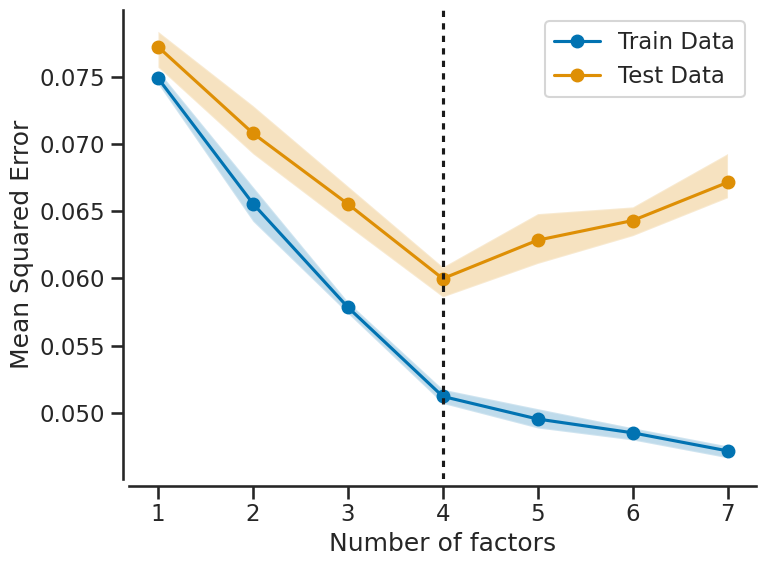

In [ ]:
fig, ax = plt.subplots(1, figsize=(8, 6))

ax.plot(groups["MSE"]["mean"]["Train"], 'o-', label="Train Data")
ax.plot(groups["MSE"]["mean"]["Test"], 'o-', label="Test Data")

ax.fill_between(groups["MSE"]["5%"]["Train"].index, groups["MSE"]["5%"]["Train"],
                groups["MSE"]["95%"]["Train"], alpha=0.25)
ax.fill_between(groups["MSE"]["5%"]["Test"].index, groups["MSE"]["5%"]["Test"],
                groups["MSE"]["95%"]["Test"], alpha=0.25)

inflection = (groups["MSE"]["mean"]["Test"] > groups["MSE"]["mean"]["Test"].shift()).idxmax() - 1

ax.axvline(inflection, color='k', dashes=[2, 2])

sns.despine(offset=5)
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Number of factors")
ax.legend()
plt.tight_layout()

## Trying on Our Data

In [ ]:
# Make sure nnlsm_blockpivot is already defined in your notebook
nnlstsq = nnlsm_blockpivot

def censored_nnlstsq2(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None]  # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:])  # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n_idx in range(B.shape[1]):
        try:
            X[n_idx] = nnlstsq(T[n_idx], rhs[n_idx], is_input_prod=True)[0].T
        except np.linalg.LinAlgError:
            X[n_idx] = np.zeros((A.shape[1],))

    return X.T


def cv_nmf2(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    Args
    ----
    data (ndarray)    : m x n matrix
    rank (int)        : the desired output rank (number of factors)
    M (ndarray)       : m x n binary matrix (zeros indicate heldout values)
    p_holdout (float) : fraction of values to hold out
    tol (float)       : tolerance for convergence
    verbose (bool)    : print debug info
    max_iter (int)    : maximum iterations

    Returns
    -------
    U, Vt, train_err, test_err, converged
    """

    # create the masking matrix if not provided
    if M is None:
        M = np.random.rand(*data.shape) > p_holdout
        min_valid = rank + 1

        # ensure enough True values per row
        for i in range(M.shape[0]):
            if M[i].sum() < min_valid:
                needed = min_valid - M[i].sum()
                zero_indices = np.where(~M[i])[0]
                if len(zero_indices) >= needed:
                    M[i, np.random.choice(zero_indices, size=needed, replace=False)] = True

        # ensure enough True values per column
        for j in range(M.shape[1]):
            if M[:, j].sum() < min_valid:
                needed = min_valid - M[:, j].sum()
                zero_indices = np.where(~M[:, j])[0]
                if len(zero_indices) >= needed:
                    M[np.random.choice(zero_indices, size=needed, replace=False), j] = True

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    mse = 100
    converged = False

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq2(U, data, M)
        U = censored_nnlstsq2(Vt.T, data.T, M.T).T

        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse

        if verbose:
            train_pct = 100 * M.sum() / M.size
            print(f"\tIter {itr+1} = {diff:.5f}")
            print(f"\tTrain/Test = {train_pct:.2f}/{100-train_pct:.2f}")

    # compute train/test errors
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged


In [ ]:
#importing data from Modulair MOD-00683
df = pd.read_csv('/content/sample_data/MOD-00683.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/MOD-00683.csv'

In [ ]:
#only including columns of interest and non na rows
COLS_TO_INCLUDE = ['timestamp_local','co', 'no2', 'o3', 'no', 'bin0', 'bin1', 'bin2','bin3','bin4','bin5']
df = df[COLS_TO_INCLUDE]
df.dropna()
df.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2025-12-29T11:55:02Z,NaN,NaN,NaN,NaN,42.941,17.835,6.328,1.280,0.876,0.303
1,2025-12-29T11:54:02Z,NaN,NaN,NaN,NaN,41.879,16.737,5.744,1.112,0.770,0.244
2,2025-12-29T11:53:02Z,NaN,NaN,NaN,NaN,42.907,16.337,6.045,1.202,0.752,0.219
3,2025-12-29T11:35:06Z,NaN,NaN,NaN,NaN,36.847,14.615,5.084,1.031,0.690,0.284
4,2025-12-29T11:34:06Z,NaN,NaN,NaN,NaN,35.261,13.451,5.089,0.894,0.498,0.182


In [ ]:
#converting to datetime
df['timestamp_local'] = pd.to_datetime(df['timestamp_local'],
                                       format='%Y-%m-%dT%H:%M:%SZ',
                                       exact=False)
df.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2025-12-29 11:55:02,NaN,NaN,NaN,NaN,42.941,17.835,6.328,1.280,0.876,0.303
1,2025-12-29 11:54:02,NaN,NaN,NaN,NaN,41.879,16.737,5.744,1.112,0.770,0.244
2,2025-12-29 11:53:02,NaN,NaN,NaN,NaN,42.907,16.337,6.045,1.202,0.752,0.219
3,2025-12-29 11:35:06,NaN,NaN,NaN,NaN,36.847,14.615,5.084,1.031,0.690,0.284
4,2025-12-29 11:34:06,NaN,NaN,NaN,NaN,35.261,13.451,5.089,0.894,0.498,0.182


In [ ]:
#taking hourly average of df. round to floor of the hour
df = df.groupby(df['timestamp_local'].dt.floor('h')).agg(co = ('co','mean'),
                                                         no2 = ('no2','mean'),
                                                         o3 = ('o3','mean'),
                                                         no = ('no','mean'),
                                                         bin0 = ('bin0','mean'),
                                                         bin1 = ('bin1','mean'),
                                                         bin2 = ('bin2','mean'),
                                                         bin3 = ('bin3','mean'),
                                                         bin4 = ('bin4','mean'),
                                                         bin5 = ('bin5','mean')).reset_index()

df = df.round(decimals = 2)
df = df.dropna()

In [ ]:
df.to_csv('/content/sample_data/MOD-00683_timeseries_hourly_scaled.csv')

In [ ]:
df = df.sample(frac=0.2)
df = df.set_index('timestamp_local')

def maximum_absolute_scaling(df):
    # copy the dataframe
    df_scaled = df.copy()
    # apply maximum absolute scaling
    for column in df_scaled.columns:
        df_scaled[column] = df_scaled[column]  / df_scaled[column].abs().max()
    return df_scaled

# call the maximum_absolute_scaling function
df_scaled = maximum_absolute_scaling(df)

df_scaled.head(10)

,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
timestamp_local,,,,,,,,,,
2025-05-06 16:00:00,0.496845,0.388402,0.591718,0.044031,0.235495,0.135317,0.128322,0.163580,0.295082,0.465278
2025-07-12 18:00:00,0.536391,0.191006,0.515922,0.051370,0.168719,0.038388,0.029613,0.027778,0.049180,0.055556
2025-05-06 05:00:00,0.531032,0.273846,0.313839,0.069472,0.467022,0.448816,0.256644,0.237654,0.344262,0.361111
2025-09-30 12:00:00,0.523555,0.394320,0.534447,0.049902,0.086891,0.021113,0.017464,0.018519,0.032787,0.041667
2025-08-20 00:00:00,0.510445,0.221302,0.454898,0.056751,0.035988,0.016635,0.015186,0.015432,0.024590,0.048611
2025-04-21 03:00:00,0.588867,0.579408,0.604795,0.052593,0.034483,0.008637,0.007593,0.006173,0.008197,0.013889
2025-08-29 17:00:00,0.468082,0.223432,0.656859,0.053327,0.041872,0.007997,0.005315,0.006173,0.008197,0.006944
2025-05-22 04:00:00,0.459662,0.304379,0.541349,0.057241,0.053366,0.020793,0.034928,0.058642,0.118852,0.166667
2025-10-26 00:00:00,0.592245,0.647101,0.388546,0.040117,0.034346,0.010877,0.007593,0.003086,0.008197,0.006944


In [ ]:
replicates = 10

ranks = np.arange(1, 7)

frame = pd.DataFrame()

# fit the models
for rnk, j in itertools.product(ranks, range(replicates)):
    print ("Rank {}.{}".format(rnk, j))

    tr, te, converged = cv_nmf2(df_scaled.values, rnk, verbose=True, tol=1e-4, max_iter=150, p_holdout=0.2)[2:]

    if not converged:
        print ("there was a convergence issue: {}".format(rnk))

    else:
        new_rows = pd.DataFrame([
            {"Rank": rnk, "MSE": tr, "Group": "Train", "Converged": converged},
            {"Rank": rnk, "MSE": te, "Group": "Test", "Converged": converged}])

        frame = pd.concat([frame, new_rows], ignore_index=True)

frame["Rank"] = frame["Rank"].astype(np.int32)

# prepare for plotting
groups = frame.groupby(["Group", "Rank"]).describe(percentiles=[0.05, 0.95])

Rank 1.0
	Iter 1 = 99.98812
	Train/Test = 79.29/20.71
Rank 1.1
	Iter 1 = 99.98806
	Train/Test = 79.99/20.01
Rank 1.2
	Iter 1 = 99.98748
	Train/Test = 80.42/19.58
Rank 1.3
	Iter 1 = 99.98766
	Train/Test = 79.46/20.54
Rank 1.4
	Iter 1 = 99.98801
	Train/Test = 80.36/19.64
Rank 1.5
	Iter 1 = 99.98661
	Train/Test = 79.42/20.58
	Iter 2 = -0.00016
	Train/Test = 79.42/20.58
Rank 1.6
	Iter 1 = 99.98751
	Train/Test = 79.66/20.34
	Iter 2 = 0.00013
	Train/Test = 79.66/20.34
Rank 1.7
	Iter 1 = 99.98767
	Train/Test = 80.21/19.79
Rank 1.8
	Iter 1 = 99.98798
	Train/Test = 80.21/19.79
Rank 1.9
	Iter 1 = 99.98804
	Train/Test = 79.93/20.07
Rank 2.0
	Iter 1 = 99.41510
	Train/Test = 80.29/19.71
	Iter 2 = 0.57394
	Train/Test = 80.29/19.71
	Iter 3 = 0.00220
	Train/Test = 80.29/19.71
	Iter 4 = 0.00027
	Train/Test = 80.29/19.71
Rank 2.1
	Iter 1 = 99.63417
	Train/Test = 79.57/20.43
	Iter 2 = 0.35265
	Train/Test = 79.57/20.43
	Iter 3 = 0.00273
	Train/Test = 79.57/20.43
	Iter 4 = 0.00029
	Train/Test = 79.57/20.43

/tmp/ipython-input-2261680124.py:82: RuntimeWarning: overflow encountered in square
  tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
/tmp/ipython-input-2261680124.py:20: RuntimeWarning: overflow encountered in matmul
  T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:])  # n x r x r tensor


Streaming output truncated to the last 5000 lines.
	Train/Test = 80.21/19.79
	Iter 68 = -47450898036548836285472272899530047343924911349432320.00000
	Train/Test = 80.21/19.79
	Iter 69 = -577750394966345748488855168531067568388958914370076672.00000
	Train/Test = 80.21/19.79
	Iter 70 = -7025600910873004651205130431683111996759239234175369216.00000
	Train/Test = 80.21/19.79
	Iter 71 = -85342894369034286269812933408050008670989796733318332416.00000
	Train/Test = 80.21/19.79
	Iter 72 = -1035958875665592333787776946996300030859748439684336844800.00000
	Train/Test = 80.21/19.79
	Iter 73 = -12571176418436489164451120139135384449726217738311581040640.00000
	Train/Test = 80.21/19.79
	Iter 74 = -152489660965408904479512294188497151058061447513264015540224.00000
	Train/Test = 80.21/19.79
	Iter 75 = -1849095227065936685766176494833387117020634188403973870845952.00000
	Train/Test = 80.21/19.79
	Iter 76 = -22418932880789344737643496216179810528164120982238241721679872.00000
	Train/Test = 80.21/19.79


In [ ]:
groups

MSE                                                              \
           count      mean       std       min        5%       50%       95%   
Group Rank                                                                     
Test  1     10.0  0.019524  0.002008  0.017694  0.017791  0.018964  0.022754   
      2      8.0  0.026436  0.008655  0.017949  0.019003  0.023863  0.040430   
      3      2.0  0.075538  0.028153  0.055631  0.057621  0.075538  0.093454   
Train 1     10.0  0.010437  0.000186  0.010129  0.010181  0.010468  0.010679   
      2      8.0  0.006261  0.000306  0.005796  0.005894  0.006235  0.006685   
      3      2.0  0.050437  0.061815  0.006728  0.011099  0.050437  0.089776   

                      
                 max  
Group Rank            
Test  1     0.024253  
      2     0.045363  
      3     0.095445  
Train 1     0.010806  
      2     0.006799  
      3     0.094147

In [ ]:
from scipy.signal import argrelextrema

fig, ax = plt.subplots(1, figsize=(8, 6))

ax.plot(groups["MSE"]["mean"]["Train"], 'o-', label="Train Data")
ax.plot(groups["MSE"]["mean"]["Test"], 'o-', label="Test Data")

ax.fill_between(groups["MSE"]["5%"]["Train"].index, groups["MSE"]["5%"]["Train"],
                groups["MSE"]["95%"]["Train"], alpha=0.25)
ax.fill_between(groups["MSE"]["5%"]["Test"].index, groups["MSE"]["5%"]["Test"],
                groups["MSE"]["95%"]["Test"], alpha=0.25)

test_mse = groups["MSE"]["mean"]["Test"].values
ranks = groups["MSE"]["mean"]["Test"].index.values

local_min_idx = argrelextrema(test_mse, np.less)[0]

if len(local_min_idx) > 0:
    inflection = ranks[local_min_idx[0]]
    ax.axvline(inflection, color='k', dashes=[2, 2])

sns.despine(offset=5)
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Number of factors")
ax.legend()
plt.tight_layout()

NameError: name 'plt' is not defined

N_FACTORS = 4

#####